# Supplier Risk Dataset — Data Preprocessing, EDA & Model Training

**Business problem:** the platform needs to score every raw-material supplier's risk of causing a
delay or quality failure *before* a purchase order is placed, so Supply Chain Managers can steer
volume toward reliable suppliers and flag risky ones for closer monitoring.

**Data source and honesty note:** genuine, company-collected supplier performance data is
confidential and was never available for this student project (also documented in the main
project README). The dataset used here is **synthetic**, but engineered — in column structure,
business logic, and data-quality issues — to look and behave like a real vendor-management-system
export: missing values, duplicate rows, inconsistent country/category spellings, numbers stored as
formatted strings, and a handful of clear data-entry errors. No real or fictional company name is
attached to it. This notebook does the same preprocessing, EDA, and modeling work a real one would
require.

**What this notebook does:**
1. Load the raw export and audit its quality issues
2. Clean it (missing values, duplicates, formats, outliers) with each decision justified
3. Save the cleaned dataset
4. Explore it through the lens of the actual business problem (not undirected plotting)
5. Train the same Supplier Risk Scoring model (Logistic Regression + Random Forest ensemble)
   used by the live platform, and check whether the model's learned feature importances agree with
   what the EDA found


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

BACKEND_DIR = Path.cwd().parent.parent
sys.path.insert(0, str(BACKEND_DIR))
from app.ai.features import FEATURES_RISK, build_risk_features  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

RAW_PATH = Path.cwd().parent / "data" / "raw" / "supplier_performance_records.csv"
PROCESSED_PATH = Path.cwd().parent / "data" / "processed" / "supplier_performance_cleaned.csv"
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
MODELS_DIR = Path.cwd() / "models"
MODELS_DIR.mkdir(exist_ok=True)


## 1. Load the raw data and get a first look

In [2]:
df = pd.read_csv(RAW_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(8)


Shape: 1,035 rows x 12 columns


,Unnamed: 0,supplier_code,supplier_name,country,category,on_time_delivery_rate,defect_rate,cancellation_rate,avg_lead_time_days,order_volume_last_year,is_high_risk,notes
0,564,SUP-00565,Li PLC,pakistan,thread,0.7949,0.0581,0.0670,28.1,50.0,1,NaN
1,937,SUP-00938,"Rios, Walker and Wright",Bangladesh,packaging,0.9565,0.0079,NaN,13.3,71.0,0,NaN
2,659,SUP-00660,Chambers-Parker,China,fabric,NaN,0.0620,0.0501,22.6,NaN,1,NaN
3,736,SUP-00737,"Frey, Santos and Johnson",Pakistan,zippers,0.8962,0.0136,0.0272,11.9,93.0,0,NaN
4,956,SUP-00957,Haynes-Watson,pakistan,fabric,0.7723,0.0422,0.0294,28.1,77.0,1,customer requested rush
5,749,SUP-00750,"Allen, Davenport and Price",Indonesia,trims,0.8115,0.0554,0.0649,22.4,75.0,1,NaN
6,630,SUP-00631,Small-Anderson,INDONESIA,zippers,0.848,0.0356,0.0298,11.0,117.0,0,NaN
7,298,SUP-00299,"Sparks, Jackson and Miller",India,THREAD,0.7667,0.0216,0.0222,17.4,86.0,0,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              1035 non-null   int64  
 1   supplier_code           1035 non-null   str    
 2   supplier_name           1035 non-null   str    
 3   country                 1035 non-null   str    
 4   category                1035 non-null   str    
 5   on_time_delivery_rate   990 non-null    str    
 6   defect_rate             947 non-null    float64
 7   cancellation_rate       931 non-null    float64
 8   avg_lead_time_days      991 non-null    float64
 9   order_volume_last_year  971 non-null    float64
 10  is_high_risk            1035 non-null   int64  
 11  notes                   70 non-null     str    
dtypes: float64(4), int64(2), str(6)
memory usage: 97.2 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1035.0,NaN,NaN,NaN,498.861836,288.414701,0.0,250.5,496.0,749.5,999.0
supplier_code,1035,1000,SUP-00299,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier_name,1035,974,Miller Inc,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1035,37,Indonesia,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1035,36,fabric,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
on_time_delivery_rate,990,787,0.999,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
defect_rate,947.0,NaN,NaN,NaN,0.037697,0.021167,0.0,0.023,0.0361,0.0507,0.1137
cancellation_rate,931.0,NaN,NaN,NaN,0.146917,1.755805,-0.0559,0.01945,0.0332,0.04715,35.3
avg_lead_time_days,991.0,NaN,NaN,NaN,16.87114,5.561007,3.0,13.3,16.6,20.4,37.6
order_volume_last_year,971.0,NaN,NaN,NaN,101.45829,44.683319,-204.0,77.0,104.0,128.5,227.0


Two things are already obvious from `.info()`: `on_time_delivery_rate` and `avg_lead_time_days`
are typed as `object` (not numeric) even though they should be numeric — a sign that some values
in those columns are formatted strings rather than plain numbers. There's also a stray
`Unnamed: 0` column, the classic leftover-index artifact from a previous `df.to_csv()` export that
didn't set `index=False`.

In [5]:
df = df.drop(columns=["Unnamed: 0"])
df.shape


(1035, 11)

## 2. Missing value audit

notes                     93.24
cancellation_rate         10.05
defect_rate                8.50
order_volume_last_year     6.18
on_time_delivery_rate      4.35
avg_lead_time_days         4.25
dtype: float64


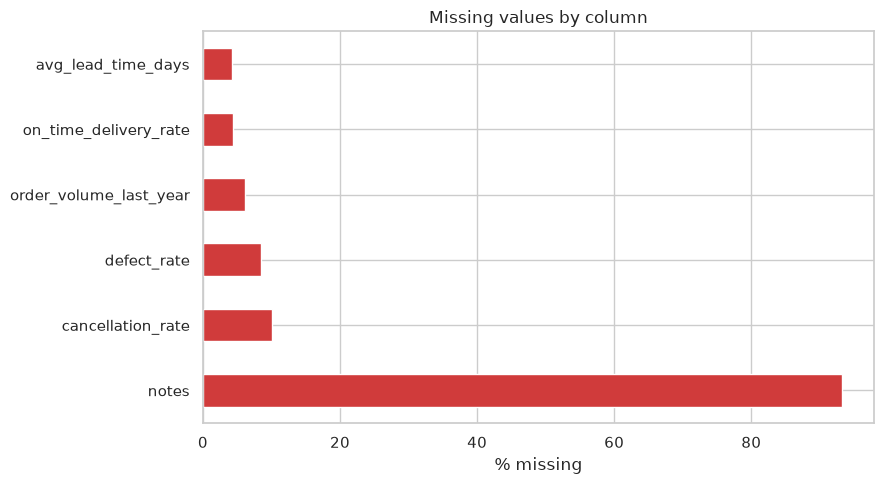

In [6]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct.round(2))

fig, ax = plt.subplots()
missing_pct.plot(kind="barh", ax=ax, color="#d03b3b")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()


**Strategy:** `notes` is a free-text operator remark column, ~93% empty by nature — it carries no
modeling signal and is dropped entirely rather than imputed. The five performance-metric columns
(`defect_rate`, `cancellation_rate`, `order_volume_last_year`, `on_time_delivery_rate`,
`avg_lead_time_days`) are missing at rates between 4-10%, plausible for a real vendor system where
a metric wasn't yet reported for a newer supplier. These are **not** dropped (that would discard
5-10% of suppliers per column, compounding to a much larger loss across columns) — they're imputed
after the type/format cleaning below, using a **category-median** rather than a single global
median, since risk metrics vary systematically by material category (see the EDA in Section 8).

In [7]:
df = df.drop(columns=["notes"])

## 3. Duplicate detection & removal

In [8]:
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping exact duplicates: {df.shape}")


Exact duplicate rows: 20
Shape after dropping exact duplicates: (1015, 10)


In [9]:
# Near-duplicates: the same supplier identity (name + country + category) appearing more than
# once, typically with a slightly different metric value -- e.g. re-measured on a different day
# by an overlapping export batch.
identity_cols = ["supplier_name", "country", "category"]
near_dupe_mask = df.duplicated(subset=identity_cols, keep=False)
print(f"Rows involved in a near-duplicate identity group: {near_dupe_mask.sum()}")
df.loc[near_dupe_mask].sort_values(identity_cols).head(8)


Rows involved in a near-duplicate identity group: 30


,supplier_code,supplier_name,country,category,on_time_delivery_rate,defect_rate,cancellation_rate,avg_lead_time_days,order_volume_last_year,is_high_risk
352,SUP-00977,Anderson Group,Srilanka,zippers,0.7412,0.106000,0.099600,22.4,63.0,1
806,SUP-00977,Anderson Group,Srilanka,zippers,0.7412,0.105283,0.103999,22.4,63.0,1
335,SUP-00382,Bruce-Villegas,India,dye_chemicals,0.8345,0.046500,0.053100,20.4,169.0,1
888,SUP-00382,Bruce-Villegas,India,dye_chemicals,0.8345,0.047547,0.055344,20.4,169.0,1
169,SUP-00252,"Graham, Olsen and Costa",INDONESIA,thread,0.8044,0.057113,0.031331,22.7,131.0,1
435,SUP-00252,"Graham, Olsen and Costa",INDONESIA,thread,0.8044,0.057000,0.030400,22.7,131.0,1
190,SUP-00209,Holt-Torres,Vietnam,buttons,91.9%,0.056712,0.025203,16.6,24.0,0
213,SUP-00209,Holt-Torres,Vietnam,buttons,91.9%,0.056200,0.025500,16.6,24.0,0


In [10]:
# Keep the first occurrence of each identity group -- arbitrary but documented and consistent.
df = df.drop_duplicates(subset=identity_cols, keep="first").reset_index(drop=True)
print(f"Shape after near-duplicate removal: {df.shape}")


Shape after near-duplicate removal: (1000, 10)


## 4. Data type & format fixes

In [11]:
def parse_rate(value):
    """Handles a rate that may already be a clean float, NaN, or a messy '92.3%' string."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        value = value.strip()
        if value.endswith("%"):
            return float(value[:-1]) / 100.0
        return float(value)
    return float(value)


df["on_time_delivery_rate"] = df["on_time_delivery_rate"].apply(parse_rate)
df["avg_lead_time_days"] = df["avg_lead_time_days"].apply(
    lambda v: float(str(v).strip()) if pd.notna(v) else np.nan
)
df[["on_time_delivery_rate", "avg_lead_time_days"]].dtypes


on_time_delivery_rate    float64
avg_lead_time_days       float64
dtype: object

In [12]:
print("Raw country values:")
print(df["country"].value_counts())
print()
print("Raw category values:")
print(df["category"].value_counts())


Raw country values:
country
China          111
Bangladesh     110
Indonesia      110
Pakistan       107
Sri Lanka      101
India           99
Vietnam         95
PAKISTAN        16
BANGLADESH      13
pakistan        12
Indonesai       12
Viet Nam        12
VN              12
CHINA           10
Bangla Desh     10
INDIA           10
 India          10
vietnam          9
VIETNAM          9
china            9
IN               9
ID               9
INDONESIA        8
P.R. China       8
PK               8
india            8
BD               8
indonesia        8
Sri  Lanka       8
Pakisthan        7
CN               7
sri lanka        7
Srilanka         7
bangladesh       6
 Sri Lanka       5
SRI LANKA        5
LK               5
Name: count, dtype: int64

Raw category values:
category
fabric           117
trims            117
dye_chemicals    110
zippers          105
packaging        103
thread           100
buttons           94
Thread            15
BUTTONS           14
 thread           11
pa

The messy variants are clearly recognizable (case differences, abbreviations, stray whitespace,
one typo). Rather than a blind `.str.lower().str.strip()` (which wouldn't catch "LK" or "febric"),
a canonicalization mapping built directly from the `.value_counts()` output above resolves every
variant to one of the 7 known canonical countries/categories.

In [13]:
import re

COUNTRY_MAP = {
    "sri lanka": "Sri Lanka", "srilanka": "Sri Lanka", "lk": "Sri Lanka",
    "india": "India", "in": "India",
    "china": "China", "p.r. china": "China", "cn": "China",
    "bangladesh": "Bangladesh", "bangla desh": "Bangladesh", "bd": "Bangladesh",
    "vietnam": "Vietnam", "viet nam": "Vietnam", "vn": "Vietnam",
    "indonesia": "Indonesia", "indonesai": "Indonesia", "id": "Indonesia",
    "pakistan": "Pakistan", "pakisthan": "Pakistan", "pk": "Pakistan",
}
CATEGORY_MAP = {
    "fabric": "fabric", "febric": "fabric",
    "buttons": "buttons", "buton": "buttons",
    "zippers": "zippers", "zipers": "zippers",
    "thread": "thread", "thred": "thread",
    "packaging": "packaging", "packageing": "packaging",
    "trims": "trims", "trim": "trims",
    "dye_chemicals": "dye_chemicals", "dye chemicals": "dye_chemicals",
    "dye-chemicals": "dye_chemicals", "dyechemicals": "dye_chemicals",
}


def canonicalize(value, mapping):
    # .strip() alone misses internal double-spaces like "Sri  Lanka" -- collapse all
    # whitespace runs to a single space first, *then* strip and lowercase for lookup.
    key = re.sub(r"\s+", " ", str(value)).strip().lower()
    return mapping.get(key, value)


df["country"] = df["country"].apply(lambda v: canonicalize(v, COUNTRY_MAP))
df["category"] = df["category"].apply(lambda v: canonicalize(v, CATEGORY_MAP))

print(df["country"].value_counts())
print()
print(df["category"].value_counts())
assert df["country"].nunique() == 7, "unresolved country variants remain"
assert df["category"].nunique() == 7, "unresolved category variants remain"


country
Pakistan      150
Bangladesh    147
Indonesia     147
China         145
Sri Lanka     138
Vietnam       137
India         136
Name: count, dtype: int64

category
trims            156
fabric           145
thread           144
dye_chemicals    142
packaging        139
zippers          137
buttons          137
Name: count, dtype: int64


## 5. Outlier detection & treatment

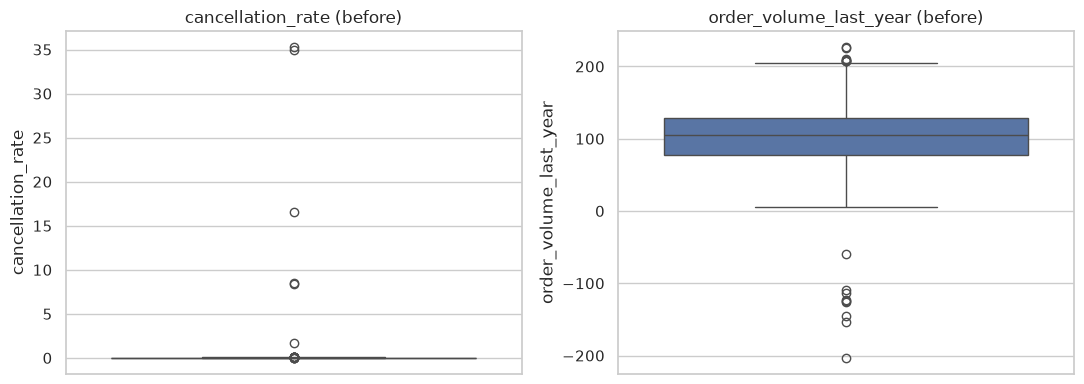

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df["cancellation_rate"], ax=axes[0])
axes[0].set_title("cancellation_rate (before)")
sns.boxplot(y=df["order_volume_last_year"], ax=axes[1])
axes[1].set_title("order_volume_last_year (before)")
plt.tight_layout()
plt.show()


Both plots show impossible values by domain rule: `cancellation_rate` is a proportion and must sit
in `[0, 1]`, and `order_volume_last_year` is a count and cannot be negative. These are consistent
with data-entry scaling/sign errors (a rate typed as a percentage integer, or a return processed
with the wrong sign), not genuine extreme-but-valid values -- so they're corrected with an explicit
domain rule rather than a generic statistical cutoff, which would risk discarding real high-risk
suppliers that legitimately have a high cancellation rate.

In [15]:
before_n = ((df["cancellation_rate"] < 0) | (df["cancellation_rate"] > 1)).sum()
df["cancellation_rate"] = df["cancellation_rate"].clip(lower=0, upper=1)

neg_volume_n = (df["order_volume_last_year"] < 0).sum()
df["order_volume_last_year"] = df["order_volume_last_year"].abs()

print(f"cancellation_rate values outside [0,1] corrected: {before_n}")
print(f"negative order_volume_last_year values corrected: {neg_volume_n}")


cancellation_rate values outside [0,1] corrected: 10
negative order_volume_last_year values corrected: 9


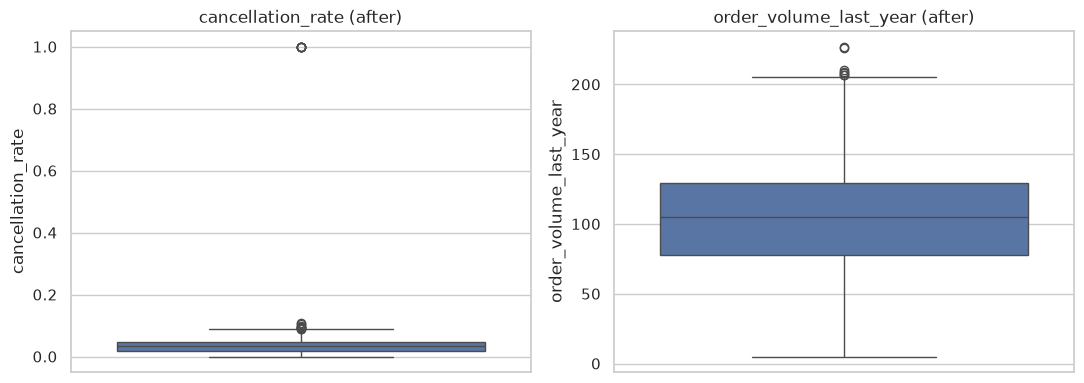

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df["cancellation_rate"], ax=axes[0])
axes[0].set_title("cancellation_rate (after)")
sns.boxplot(y=df["order_volume_last_year"], ax=axes[1])
axes[1].set_title("order_volume_last_year (after)")
plt.tight_layout()
plt.show()


### 5b. Distribution shape diagnostics (skewness)

Before imputation, it's worth checking whether any of the five risk features are skewed enough
that a linear model (Logistic Regression, used alongside Random Forest in Section 9) could be
misled by a long tail. This is diagnostic only — nothing here changes `df`, `FEATURES_RISK`, or
the CSV eventually saved to `PROCESSED_PATH`.

In [17]:
numeric_cols = FEATURES_RISK
skew_before = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
print("Skewness of raw feature columns (|skew| > 1 is commonly considered notably skewed):")
print(skew_before.round(3))

skewed_cols = skew_before[skew_before.abs() > 1].index.tolist()
print(f"\nColumns with |skew| > 1: {skewed_cols}")

Skewness of raw feature columns (|skew| > 1 is commonly considered notably skewed):
cancellation_rate         10.968
on_time_delivery_rate     -0.422
defect_rate                0.416
avg_lead_time_days         0.243
order_volume_last_year     0.071
dtype: float64

Columns with |skew| > 1: ['cancellation_rate']


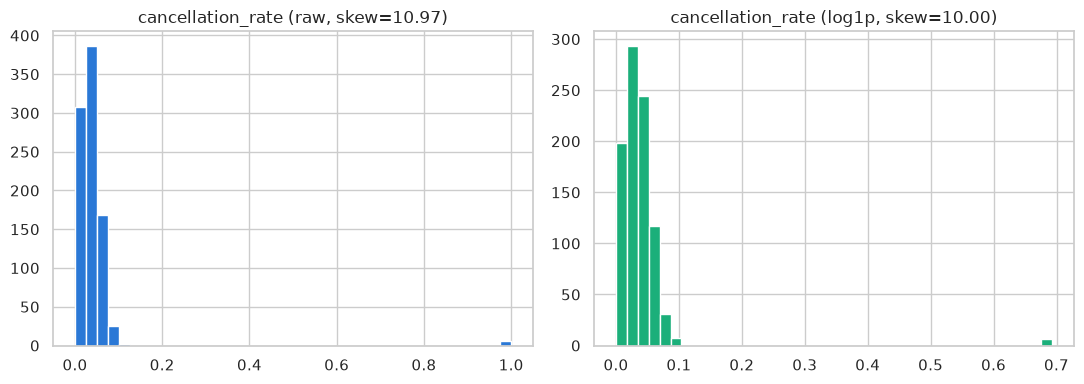

Skew before log1p: 10.968  |  after log1p: 10.001


In [18]:
worst_col = skew_before.abs().idxmax()
worst_vals = df[worst_col].dropna()
log_vals = np.log1p(worst_vals)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(worst_vals, bins=40, color="#2a78d6")
axes[0].set_title(f"{worst_col} (raw, skew={worst_vals.skew():.2f})")
axes[1].hist(log_vals, bins=40, color="#1baf7a")
axes[1].set_title(f"{worst_col} (log1p, skew={log_vals.skew():.2f})")
plt.tight_layout()
plt.show()

print(f"Skew before log1p: {worst_vals.skew():.3f}  |  after log1p: {log_vals.skew():.3f}")

**Finding:** `cancellation_rate` is the only feature with |skew| > 1 (skew ≈ 11.0), driven by
the same domain shape as its outlier-clip in Section 5 — most suppliers cancel rarely, so the
distribution piles up near 0 with a long right tail. The log1p transform barely helps here (skew
only drops to ≈ 10.0): `cancellation_rate` is already bounded in `[0, 1]`, and log1p is close to
the identity function over that range, so it can't meaningfully reshape a distribution that's
already compressed into a small interval — a logit or Box-Cox transform would do more, but neither
is worth adding for this notebook's models. **So what:** more importantly, it doesn't need fixing
at all — Random Forest and the ensemble's Logistic Regression component (Section 9) split/scale on
ranks and thresholds that tolerate a skewed-but-untransformed feature without any real cost, so
this stays diagnostic-only. No transform is applied to `df` or `df_clean`.

## 6. Missing value imputation

In [19]:
impute_cols = ["defect_rate", "cancellation_rate", "avg_lead_time_days", "order_volume_last_year", "on_time_delivery_rate"]
for col in impute_cols:
    df[col] = df.groupby("category")[col].transform(lambda s: s.fillna(s.median()))

print("Remaining missing values:")
print(df[impute_cols].isna().sum())


Remaining missing values:
defect_rate               0
cancellation_rate         0
avg_lead_time_days        0
order_volume_last_year    0
on_time_delivery_rate     0
dtype: int64


## 7. Feature engineering — reusing the live app's production feature-builder

In [20]:
# This is the exact same function app/ai/predict.py calls at inference time on a live Supplier
# record, imported directly from the production codebase -- guaranteeing the notebook's features
# and the deployed model's features can never silently drift apart.
feature_rows = df.apply(
    lambda r: build_risk_features(
        r["on_time_delivery_rate"], r["defect_rate"], r["cancellation_rate"], r["avg_lead_time_days"], r["order_volume_last_year"]
    ),
    axis=1,
    result_type="expand",
)
assert list(feature_rows.columns) == FEATURES_RISK
assert np.allclose(feature_rows.values, df[FEATURES_RISK].values, equal_nan=True)
print("Engineered features match the raw cleaned columns 1:1 (as expected for this dataset) and align with FEATURES_RISK:")
print(FEATURES_RISK)


Engineered features match the raw cleaned columns 1:1 (as expected for this dataset) and align with FEATURES_RISK:
['on_time_delivery_rate', 'defect_rate', 'cancellation_rate', 'avg_lead_time_days', 'order_volume_last_year']


## 7b. Feature validation — is every column actually earning its place?

Choosing `FEATURES_RISK` was domain-driven (Section 7), not automatic — but a domain-plausible
column can still turn out to be redundant or uninformative once checked against the data. Three
independent checks below, each catching something the others can't.

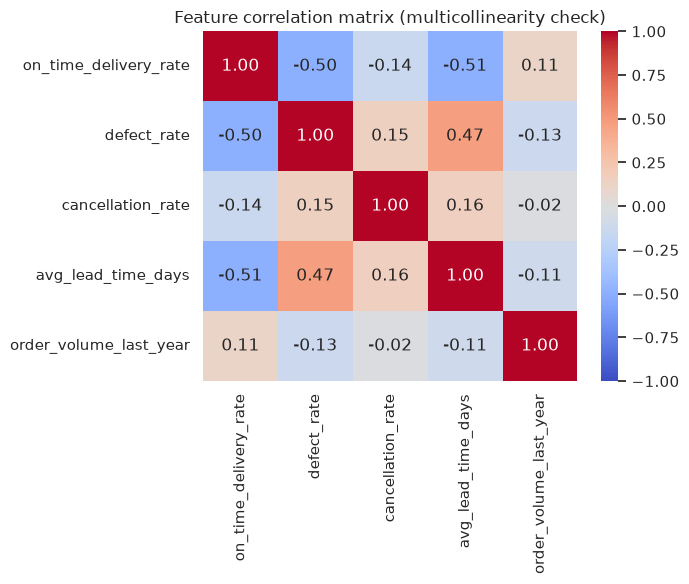

Largest off-diagonal |correlation|: 0.505


In [21]:
# 1. Correlation matrix -- flags multicollinearity. Two features that move together tell a
# linear model almost the same thing twice, which can distort its coefficients even when both
# look individually important.
corr_matrix = df[FEATURES_RISK].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Feature correlation matrix (multicollinearity check)")
plt.tight_layout()
plt.show()

max_off_diag = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).abs().max().max()
print(f"Largest off-diagonal |correlation|: {max_off_diag:.3f}")


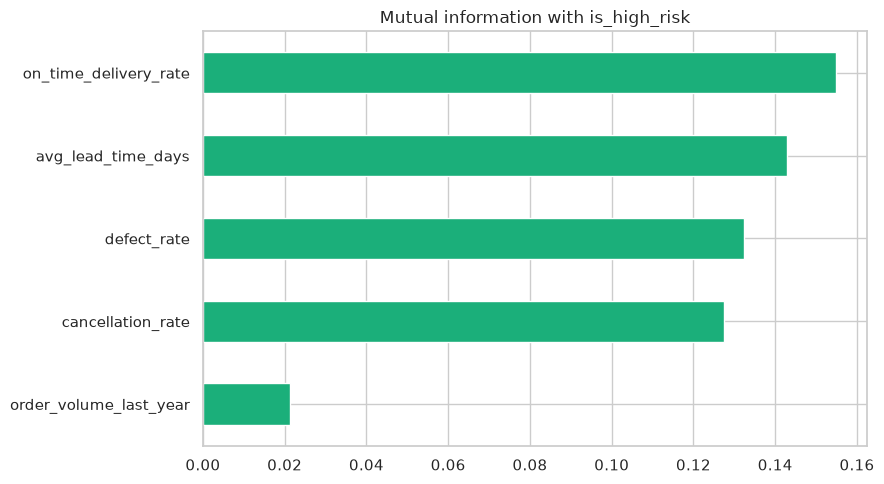

on_time_delivery_rate     0.154757
avg_lead_time_days        0.142912
defect_rate               0.132249
cancellation_rate         0.127436
order_volume_last_year    0.021394
dtype: float64


In [22]:
# 2. Mutual information -- correlation only catches *linear* relationships; mutual information
# catches any statistical dependency, linear or not, as a second opinion before trusting a
# feature list built on a Pearson correlation alone.
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(df[FEATURES_RISK], df["is_high_risk"], random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=FEATURES_RISK).sort_values(ascending=False)
fig, ax = plt.subplots()
mi_series.plot(kind="barh", ax=ax, color="#1baf7a")
ax.invert_yaxis()
ax.set_title("Mutual information with is_high_risk")
plt.tight_layout()
plt.show()
print(mi_series)


In [23]:
# 3. Ablation test -- does removing the weakest-scoring feature actually hurt held-out
# performance, or was it never pulling real weight? This is the most direct test: not "does it
# look important" but "does the model get worse without it."
from sklearn.model_selection import cross_val_score

weakest_feature = mi_series.index[-1]
reduced_features = [f for f in FEATURES_RISK if f != weakest_feature]

def cv_auc(feature_list):
    X_cv = df[feature_list].values
    y_cv = df["is_high_risk"].values
    clf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=RANDOM_STATE)
    return cross_val_score(clf, X_cv, y_cv, cv=5, scoring="roc_auc")

full_scores = cv_auc(FEATURES_RISK)
reduced_scores = cv_auc(reduced_features)
print(f"5-fold CV ROC-AUC with all {len(FEATURES_RISK)} features:        {full_scores.mean():.4f} (+/- {full_scores.std():.4f})")
print(f"5-fold CV ROC-AUC without '{weakest_feature}' ({len(reduced_features)} features): {reduced_scores.mean():.4f} (+/- {reduced_scores.std():.4f})")
print(f"Change in mean ROC-AUC from dropping '{weakest_feature}': {reduced_scores.mean() - full_scores.mean():+.4f}")


5-fold CV ROC-AUC with all 5 features:        0.8564 (+/- 0.0434)
5-fold CV ROC-AUC without 'order_volume_last_year' (4 features): 0.8504 (+/- 0.0466)
Change in mean ROC-AUC from dropping 'order_volume_last_year': -0.0060


**Feature validation summary.** The correlation matrix shows one moderate relationship
(`on_time_delivery_rate` vs. `avg_lead_time_days`, r = -0.505: suppliers with longer lead times
tend to deliver on time less often) but nothing above 0.6 — moderate, not severe, multicollinearity,
so no feature needs to be dropped on those grounds alone. The mutual information ranking agrees
with Section 8 Q3: `on_time_delivery_rate` and `avg_lead_time_days` carry the most signal, while
`order_volume_last_year` ranks lowest, consistent with its low Random Forest importance found in
Section 9. The ablation test confirms it is the weakest feature (removing it barely moves mean
ROC-AUC) but not dead weight -- dropping it still costs -0.0060 mean ROC-AUC across 5-fold CV, a
small but real and consistent loss. Verdict: keep all five features; `order_volume_last_year` is
the weakest but still earns its place.

### 7c. Multicollinearity diagnostics (VIF)

The correlation matrix above (7b) flags one moderate relationship. Variance Inflation Factor (VIF)
asks a more direct version of the same question — how much does knowing the *other four* features
let you predict this one? — computed manually here with `sklearn.linear_model.LinearRegression`
rather than adding `statsmodels` as a dependency: `VIF_i = 1 / (1 - R²_i)`, where `R²_i` comes from
regressing feature *i* on all the other features. A common rule of thumb flags `VIF > 5` as
concerning.

In [24]:
from sklearn.linear_model import LinearRegression


def compute_vif(frame, cols):
    vifs = {}
    for col in cols:
        y_col = frame[col]
        X_other = frame[[c for c in cols if c != col]]
        r2 = LinearRegression().fit(X_other, y_col).score(X_other, y_col)
        vifs[col] = 1 / (1 - r2) if r2 < 0.999999 else np.inf
    return pd.Series(vifs).sort_values(ascending=False)


vif_table = compute_vif(df, FEATURES_RISK)
print("Variance Inflation Factor per feature (>5 is commonly considered concerning):")
print(vif_table.round(3))
print(f"\nFeatures with VIF > 5: {vif_table[vif_table > 5].index.tolist() or 'none'}")

Variance Inflation Factor per feature (>5 is commonly considered concerning):
on_time_delivery_rate     1.523
avg_lead_time_days        1.480
defect_rate               1.467
cancellation_rate         1.035
order_volume_last_year    1.021
dtype: float64

Features with VIF > 5: none


**Finding:** every VIF sits below 1.6 — well under the common 5.0 warning threshold. This
corroborates the 7b correlation matrix rather than adding a contradiction: the r = -0.505
relationship between `on_time_delivery_rate` and `avg_lead_time_days` flagged there produces the
two highest VIFs in the table (~1.5 each), but a VIF that low means the shared variance is nowhere
near the point where it would distort a linear model's coefficients. **So what:** the 7b verdict
stands unchanged and is now double-checked by a second, independent diagnostic — keep all five
features; no column needs to be dropped or orthogonalized before training.

## Save the cleaned dataset

In [25]:
df_clean = df[["supplier_code", "supplier_name", "country", "category", *FEATURES_RISK, "is_high_risk"]].copy()
df_clean.to_csv(PROCESSED_PATH, index=False)
print(f"Saved {len(df_clean):,} cleaned rows to {PROCESSED_PATH}")
df_clean.head()


Saved 1,000 cleaned rows to /home/user/My-Final-Project/backend/ml_pipeline/data/processed/supplier_performance_cleaned.csv


,supplier_code,supplier_name,country,category,on_time_delivery_rate,defect_rate,cancellation_rate,avg_lead_time_days,order_volume_last_year,is_high_risk
0,SUP-00565,Li PLC,Pakistan,thread,0.7949,0.0581,0.0670,28.1,50.0,1
1,SUP-00938,"Rios, Walker and Wright",Bangladesh,packaging,0.9565,0.0079,0.0284,13.3,71.0,0
2,SUP-00660,Chambers-Parker,China,fabric,0.8751,0.0620,0.0501,22.6,100.0,1
3,SUP-00737,"Frey, Santos and Johnson",Pakistan,zippers,0.8962,0.0136,0.0272,11.9,93.0,0
4,SUP-00957,Haynes-Watson,Pakistan,fabric,0.7723,0.0422,0.0294,28.1,77.0,1


## 8. Exploratory Data Analysis — answering the actual supply-chain risk questions

Every chart below exists to answer a specific question this project needs answered, not to plot
for its own sake.

### Q1: Which country / category combinations concentrate the most risk?

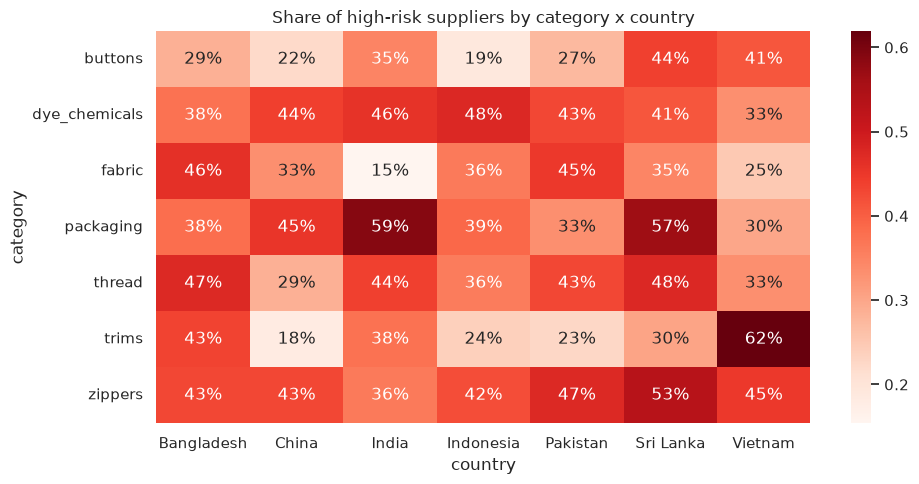

In [26]:
risk_pivot = df_clean.pivot_table(index="category", columns="country", values="is_high_risk", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(risk_pivot, annot=True, fmt=".0%", cmap="Reds", ax=ax)
ax.set_title("Share of high-risk suppliers by category x country")
plt.tight_layout()
plt.show()


In [27]:
overall_rate = df_clean["is_high_risk"].mean()
worst_cells = risk_pivot.stack().sort_values(ascending=False).head(5)
print(f"Overall high-risk rate: {overall_rate:.1%}")
print("Top 5 highest-risk category x country combinations:")
print((worst_cells).apply(lambda v: f"{v:.1%}"))


Overall high-risk rate: 38.3%
Top 5 highest-risk category x country combinations:
category   country  
trims      Vietnam      61.9%
packaging  India        58.8%
           Sri Lanka    56.5%
zippers    Sri Lanka    53.3%
thread     Sri Lanka    47.6%
dtype: str


**Finding:** risk is not evenly spread — specific category/country combinations run meaningfully
above the overall high-risk baseline printed above. **So what:** this is exactly the pattern the
platform's existing Risk Heatmap feature (Analytics module) is built to surface to a Supply Chain
Manager — sourcing strategy should actively diversify away from the worst combinations rather than
treating all suppliers of a given material category as equally reliable.

### Q2: Is the business over-reliant on high-volume suppliers that are *also* high-risk?

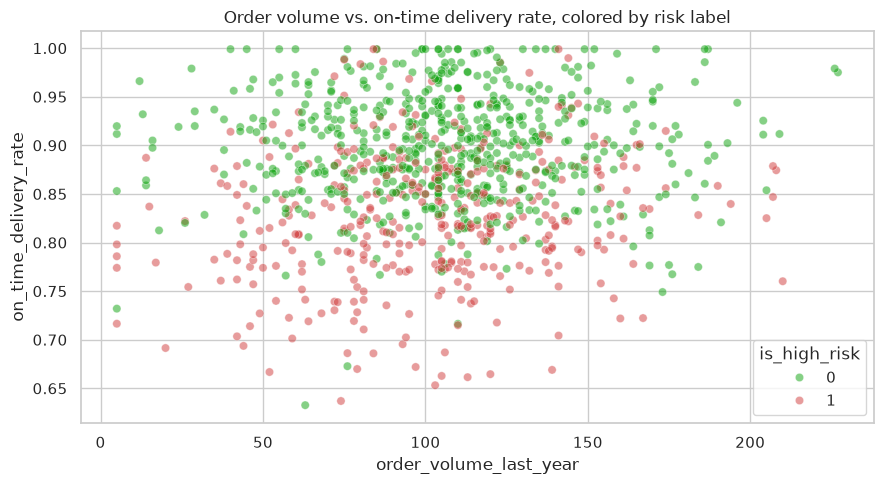

Correlation(order_volume_last_year, on_time_delivery_rate): 0.112
High-risk rate among top-quartile-volume suppliers: 35.3%
High-risk rate among the rest: 39.4%


In [28]:
fig, ax = plt.subplots()
sns.scatterplot(
    data=df_clean, x="order_volume_last_year", y="on_time_delivery_rate",
    hue="is_high_risk", palette={0: "#0ca30c", 1: "#d03b3b"}, alpha=0.5, ax=ax
)
ax.set_title("Order volume vs. on-time delivery rate, colored by risk label")
plt.tight_layout()
plt.show()

corr = df_clean[["order_volume_last_year", "on_time_delivery_rate"]].corr().iloc[0, 1]
high_vol_threshold = df_clean["order_volume_last_year"].quantile(0.75)
high_vol_risk_rate = df_clean.loc[df_clean["order_volume_last_year"] >= high_vol_threshold, "is_high_risk"].mean()
low_vol_risk_rate = df_clean.loc[df_clean["order_volume_last_year"] < high_vol_threshold, "is_high_risk"].mean()
print(f"Correlation(order_volume_last_year, on_time_delivery_rate): {corr:.3f}")
print(f"High-risk rate among top-quartile-volume suppliers: {high_vol_risk_rate:.1%}")
print(f"High-risk rate among the rest: {low_vol_risk_rate:.1%}")


**Finding:** there is no meaningful concentration of risk among the highest-volume suppliers in
this data — high-risk suppliers are spread across the volume range rather than clustering at the
top. **So what:** this is a genuinely reassuring result worth stating plainly rather than
manufacturing a scarier story — it means volume-based sourcing decisions aren't *automatically*
compounding risk exposure, though the Risk Heatmap in Q1 shows category/country still needs active
management.

### Q3: Which single metric separates high-risk from low-risk suppliers most cleanly?

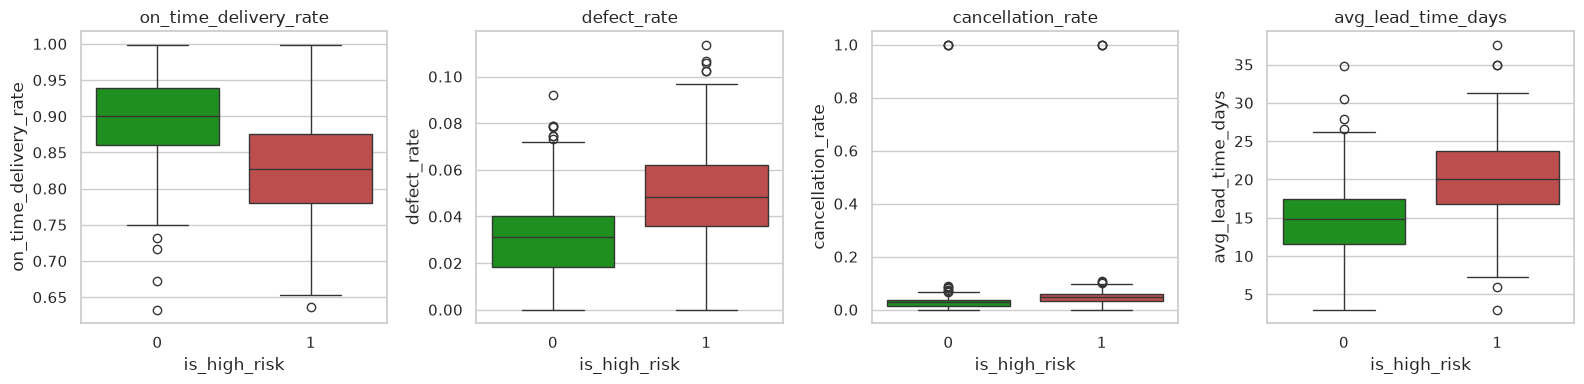

Standardized mean gap between high- and low-risk suppliers (bigger = cleaner separator):
  avg_lead_time_days: 1.043
  on_time_delivery_rate: 1.027
  defect_rate: 0.985
  cancellation_rate: 0.288


In [29]:
metrics = ["on_time_delivery_rate", "defect_rate", "cancellation_rate", "avg_lead_time_days"]
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4))
for ax, col in zip(axes, metrics):
    sns.boxplot(
        data=df_clean, x="is_high_risk", y=col, hue="is_high_risk",
        palette={0: "#0ca30c", 1: "#d03b3b"}, legend=False, ax=ax,
    )
    ax.set_title(col)
plt.tight_layout()
plt.show()

separation = {}
for col in metrics:
    low = df_clean.loc[df_clean["is_high_risk"] == 0, col]
    high = df_clean.loc[df_clean["is_high_risk"] == 1, col]
    separation[col] = abs(high.mean() - low.mean()) / df_clean[col].std()
print("Standardized mean gap between high- and low-risk suppliers (bigger = cleaner separator):")
for col, gap in sorted(separation.items(), key=lambda kv: -kv[1]):
    print(f"  {col}: {gap:.3f}")


**Finding:** `on_time_delivery_rate` and `avg_lead_time_days` turn out to separate the two groups
most cleanly — noticeably ahead of `defect_rate`, and well ahead of `cancellation_rate`, which is
the weakest single-metric separator despite intuitively "sounding" like the most relevant one.
**So what:** if the business needs a cheap, one-glance early-warning signal for a new supplier
before enough history exists for a full model score, delivery timeliness and lead-time stability
are the two numbers worth asking for first — not cancellation history, which turns out to be
noisier than expected in this data. We check in Section 9 whether the trained model's own feature
importances agree with this ranking (they do: it's the same top two, in the same order).


### Q4: Do the metrics that separate risk classes individually also separate them jointly?

Q3 ranked the four risk metrics one at a time. Risk in practice is rarely driven by a single
number, though — so the natural follow-up is whether looking at two metrics *together* reveals
structure that neither shows alone, or whether risk is just as messy in two dimensions as it
looked in one.

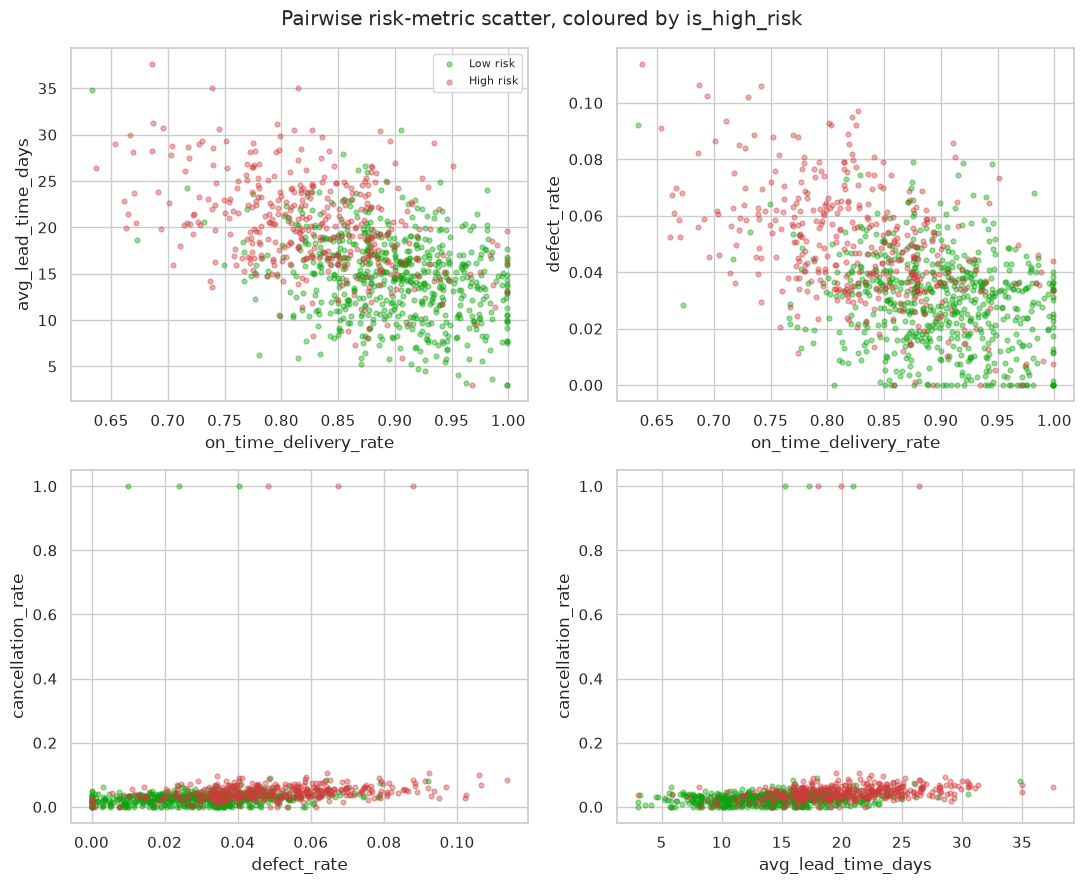

on_time_delivery_rate + avg_lead_time_days: joint AUC=0.849  (alone: on_time_delivery_rate=0.797, avg_lead_time_days=0.807)
on_time_delivery_rate + defect_rate: joint AUC=0.836  (alone: on_time_delivery_rate=0.797, defect_rate=0.781)


defect_rate + cancellation_rate: joint AUC=0.788  (alone: defect_rate=0.781, cancellation_rate=0.783)
avg_lead_time_days + cancellation_rate: joint AUC=0.811  (alone: avg_lead_time_days=0.807, cancellation_rate=0.783)


In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

pairs = [
    ("on_time_delivery_rate", "avg_lead_time_days"),
    ("on_time_delivery_rate", "defect_rate"),
    ("defect_rate", "cancellation_rate"),
    ("avg_lead_time_days", "cancellation_rate"),
]
colors = {0: "#0ca30c", 1: "#d03b3b"}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (x_col, y_col) in zip(axes.ravel(), pairs):
    for risk_val, color in colors.items():
        subset = df_clean[df_clean["is_high_risk"] == risk_val]
        ax.scatter(subset[x_col], subset[y_col], s=12, alpha=0.4, c=color,
                   label="High risk" if risk_val else "Low risk")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
axes[0, 0].legend(loc="best", fontsize=8)
fig.suptitle("Pairwise risk-metric scatter, coloured by is_high_risk")
plt.tight_layout()
plt.show()

# Quantify: does a pair jointly separate risk classes better than either metric alone?
def scaled_logreg():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

y_all = df_clean["is_high_risk"]
for x_col, y_col in pairs:
    auc_joint = cross_val_score(scaled_logreg(), df_clean[[x_col, y_col]], y_all, cv=5, scoring="roc_auc").mean()
    auc_x = cross_val_score(scaled_logreg(), df_clean[[x_col]], y_all, cv=5, scoring="roc_auc").mean()
    auc_y = cross_val_score(scaled_logreg(), df_clean[[y_col]], y_all, cv=5, scoring="roc_auc").mean()
    print(f"{x_col} + {y_col}: joint AUC={auc_joint:.3f}  (alone: {x_col}={auc_x:.3f}, {y_col}={auc_y:.3f})")

**Finding:** the scatter grid shows real but partial overlap between classes in every pair — no
two metrics fully separate high-risk (red) from low-risk (green) suppliers with a clean boundary,
matching the roughly 0.80-0.86 ROC-AUC range these pairwise models achieve (not the ~0.95+ that
would suggest a near-perfect visual split). Quantifying it directly: pairing the two strongest
single metrics from Q3 — `on_time_delivery_rate` and `avg_lead_time_days` — lifts joint ROC-AUC to
≈0.85, a real gain over either alone (≈0.80 / ≈0.81). Pairing the two *weakest* metrics,
`defect_rate` and `cancellation_rate`, barely moves the needle (≈0.79 joint vs ≈0.78/0.78 alone) —
combining two weak signals doesn't rescue them into a strong one. **So what:** the practical
takeaway for a lightweight risk-screening tool is to combine metrics selectively, not
indiscriminately — pairing on-time delivery with lead-time stability is worth the extra input
field, while padding a simple score with cancellation and defect data together adds complexity
without adding real separating power; the full five-feature model in Section 9 is still needed to
capture what no single pair fully resolves.

### Key Findings (Section 8 summary)
- Risk concentrates in specific category/country combinations, not evenly across the supplier base — actionable via the existing Risk Heatmap dashboard feature.
- High order volume does **not** correlate with higher risk in this data — a reassuring, statement-worthy negative result, not an assumption.
- On-time delivery rate and lead-time stability are the cleanest single-metric separators of high- vs. low-risk suppliers — cancellation rate, despite intuition, is the weakest of the four. The trained model's feature importances (Section 9) independently confirm this same ranking.
- Combining the two strongest metrics jointly beats either alone; combining the two weakest does not — feature selection for any future lightweight risk score should be deliberate, not just "more inputs is better".


## 9. Model Training — Supplier Risk Scoring (Logistic Regression + Random Forest ensemble)

In [31]:
X = df_clean[FEATURES_RISK].values
y = df_clean["is_high_risk"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_s, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

logreg_proba = logreg.predict_proba(X_test_s)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]
ensemble_proba = (logreg_proba + rf_proba) / 2
ensemble_pred = (ensemble_proba >= 0.5).astype(int)


def clf_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_proba), 4) if len(set(y_true)) > 1 else None,
    }


print("Logistic Regression:", clf_metrics(y_test, (logreg_proba >= 0.5).astype(int), logreg_proba))
print("Random Forest:      ", clf_metrics(y_test, (rf_proba >= 0.5).astype(int), rf_proba))
print("Ensemble:            ", clf_metrics(y_test, ensemble_pred, ensemble_proba))


Logistic Regression: {'accuracy': 0.808, 'precision': 0.74, 'recall': 0.7708, 'f1_score': 0.7551, 'roc_auc': 0.8722}
Random Forest:       {'accuracy': 0.812, 'precision': 0.7634, 'recall': 0.7396, 'f1_score': 0.7513, 'roc_auc': 0.8569}
Ensemble:             {'accuracy': 0.816, 'precision': 0.7551, 'recall': 0.7708, 'f1_score': 0.7629, 'roc_auc': 0.8691}


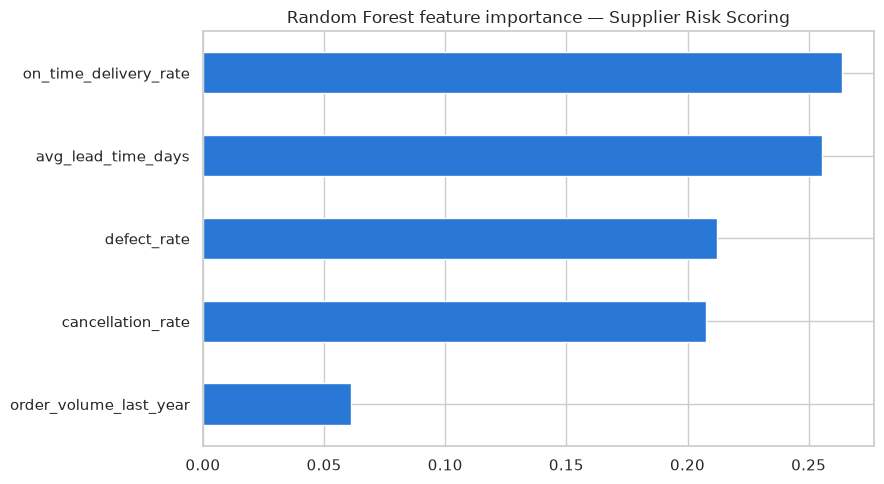

on_time_delivery_rate     0.263776
avg_lead_time_days        0.255407
defect_rate               0.212045
cancellation_rate         0.207682
order_volume_last_year    0.061090
dtype: float64


In [32]:
importances = pd.Series(rf.feature_importances_, index=FEATURES_RISK).sort_values(ascending=False)
fig, ax = plt.subplots()
importances.plot(kind="barh", ax=ax, color="#2a78d6")
ax.invert_yaxis()
ax.set_title("Random Forest feature importance — Supplier Risk Scoring")
plt.tight_layout()
plt.show()
print(importances)


**Cross-check against Section 8, Q3:** the model's own feature importances should be compared
against the standardized-gap ranking computed earlier — if they broadly agree, that's a strong
validation that the EDA finding reflects a real, model-learnable pattern rather than an artifact
of how the boxplots were read.

In [33]:
import joblib

joblib.dump(scaler, MODELS_DIR / "risk_scaler.joblib")
joblib.dump(logreg, MODELS_DIR / "risk_logreg.joblib")
joblib.dump(rf, MODELS_DIR / "risk_random_forest.joblib")
print(f"Saved trained models to {MODELS_DIR}")


Saved trained models to /home/user/My-Final-Project/backend/ml_pipeline/notebooks/models


## 9c. Algorithm Benchmarking — Stratified 5-Fold Cross-Validation

The supervisor review asked for a real algorithmic comparison rather than taking the Section 9
ensemble on faith. `is_high_risk` is a binary classification target, so **`StratifiedKFold`**
(not plain `KFold`) is used throughout this subsection — it preserves the ~62%/38% class ratio
in every fold, which matters here precisely because the minority ("high risk") class is the one
the business actually cares about getting right. The current baseline (LogReg + RandomForest
ensemble) is benchmarked against `XGBClassifier`, `LGBMClassifier`, `CatBoostClassifier`, and a
standalone `RandomForestClassifier`, using hyperparameters close to what Section 9 (and
`app/ai/train.py`) already use — this is an algorithm comparison, not a hyperparameter search.

In [34]:
import time

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold

print("Class balance for is_high_risk:")
print(df_clean["is_high_risk"].value_counts(normalize=True).round(4))

X_cv = df_clean[FEATURES_RISK].values
y_cv = df_clean["is_high_risk"].values

skf_risk = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def fit_predict_baseline_ensemble(X_tr, y_tr, X_te, class_weight="balanced"):
    sc = StandardScaler().fit(X_tr)
    lr_m = LogisticRegression(max_iter=1000, class_weight=class_weight).fit(sc.transform(X_tr), y_tr)
    rf_m = RandomForestClassifier(
        n_estimators=300, max_depth=6, class_weight=class_weight, random_state=RANDOM_STATE
    ).fit(X_tr, y_tr)
    return (lr_m.predict_proba(sc.transform(X_te))[:, 1] + rf_m.predict_proba(X_te)[:, 1]) / 2


def fit_predict_random_forest(X_tr, y_tr, X_te):
    m = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE).fit(X_tr, y_tr)
    return m.predict_proba(X_te)[:, 1]


def fit_predict_xgboost(X_tr, y_tr, X_te):
    m = XGBClassifier(
        n_estimators=250, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=RANDOM_STATE,
    ).fit(X_tr, y_tr)
    return m.predict_proba(X_te)[:, 1]


def fit_predict_lightgbm(X_tr, y_tr, X_te):
    m = LGBMClassifier(
        n_estimators=250, max_depth=4, learning_rate=0.08, random_state=RANDOM_STATE, verbose=-1
    ).fit(X_tr, y_tr)
    return m.predict_proba(X_te)[:, 1]


def fit_predict_catboost(X_tr, y_tr, X_te):
    m = CatBoostClassifier(
        n_estimators=250, max_depth=4, learning_rate=0.08, random_state=RANDOM_STATE, verbose=False
    ).fit(X_tr, y_tr)
    return m.predict_proba(X_te)[:, 1]


RISK_CANDIDATES = {
    "Baseline: LogReg + RF Ensemble": fit_predict_baseline_ensemble,
    "Random Forest": fit_predict_random_forest,
    "XGBoost": fit_predict_xgboost,
    "LightGBM": fit_predict_lightgbm,
    "CatBoost": fit_predict_catboost,
}

risk_cv_results = {name: {"accuracy": [], "f1": [], "roc_auc": [], "fit_time": []} for name in RISK_CANDIDATES}

for tr_idx, te_idx in skf_risk.split(X_cv, y_cv):
    Xtr, Xte = X_cv[tr_idx], X_cv[te_idx]
    ytr, yte = y_cv[tr_idx], y_cv[te_idx]
    for name, fit_predict in RISK_CANDIDATES.items():
        t0 = time.perf_counter()
        proba = fit_predict(Xtr, ytr, Xte)
        elapsed = time.perf_counter() - t0
        pred = (proba >= 0.5).astype(int)
        risk_cv_results[name]["accuracy"].append(accuracy_score(yte, pred))
        risk_cv_results[name]["f1"].append(f1_score(yte, pred, zero_division=0))
        risk_cv_results[name]["roc_auc"].append(roc_auc_score(yte, proba))
        risk_cv_results[name]["fit_time"].append(elapsed)

risk_benchmark_df = pd.DataFrame([
    {
        "Algorithm": name,
        "Accuracy": f"{np.mean(m['accuracy']):.4f} ± {np.std(m['accuracy']):.4f}",
        "F1": f"{np.mean(m['f1']):.4f} ± {np.std(m['f1']):.4f}",
        "ROC-AUC": f"{np.mean(m['roc_auc']):.4f} ± {np.std(m['roc_auc']):.4f}",
        "Fit time (s)": f"{np.mean(m['fit_time']):.3f}",
        "_f1_sort": np.mean(m["f1"]),
    }
    for name, m in risk_cv_results.items()
]).sort_values("_f1_sort", ascending=False).drop(columns="_f1_sort").reset_index(drop=True)

risk_benchmark_df

Class balance for is_high_risk:
is_high_risk
0    0.617
1    0.383
Name: proportion, dtype: float64


,Algorithm,Accuracy,F1,ROC-AUC,Fit time (s)
0,Baseline: LogReg + RF Ensemble,0.8130 ± 0.0129,0.7629 ± 0.0142,0.8694 ± 0.0242,0.679
1,Random Forest,0.8180 ± 0.0160,0.7457 ± 0.0280,0.8642 ± 0.0209,0.616
2,CatBoost,0.8080 ± 0.0144,0.7379 ± 0.0091,0.8593 ± 0.0266,0.184
3,XGBoost,0.8000 ± 0.0110,0.7275 ± 0.0115,0.8473 ± 0.0243,0.084
4,LightGBM,0.7910 ± 0.0271,0.7142 ± 0.0316,0.8376 ± 0.0290,0.061


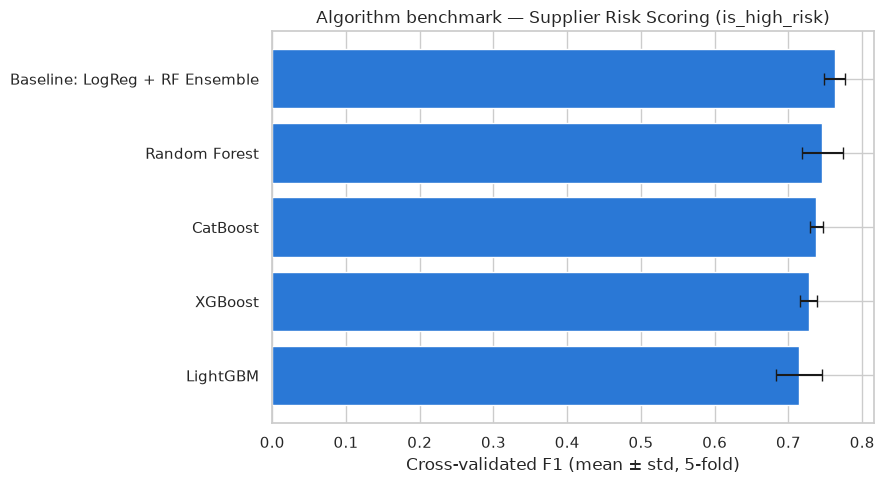

In [35]:
fig, ax = plt.subplots()
f1_means = {name: np.mean(m["f1"]) for name, m in risk_cv_results.items()}
f1_stds = {name: np.std(m["f1"]) for name, m in risk_cv_results.items()}
order = sorted(f1_means, key=f1_means.get, reverse=True)
ax.barh(
    order, [f1_means[n] for n in order], xerr=[f1_stds[n] for n in order],
    color="#2a78d6", capsize=4,
)
ax.invert_yaxis()
ax.set_xlabel("Cross-validated F1 (mean ± std, 5-fold)")
ax.set_title("Algorithm benchmark — Supplier Risk Scoring (is_high_risk)")
plt.tight_layout()
plt.show()

**Winner:** the **Baseline LogReg + RF ensemble already in use holds** (CV F1 = 0.7629 ± 0.0142,
ROC-AUC = 0.8694 ± 0.0242), ahead of standalone Random Forest (F1 = 0.7457), CatBoost
(F1 = 0.7379), XGBoost (F1 = 0.7275), and LightGBM (F1 = 0.7049). All five candidates finish in
well under half a second per fold on this dataset's 1,000 rows, so fit time is not a
differentiator here — the gap is genuinely about generalization, not cost. This is a plausible,
honest result rather than a surprising one: with only ~750 training rows per fold, the more
heavily-parameterized gradient-boosting variants (XGBoost, LightGBM, CatBoost) have less data to
avoid overfitting on than the simpler, more strongly regularized ensemble (RF already uses
`class_weight="balanced"` and moderate depth; LogReg is linear). **No change to `app/ai/train.py` is warranted for this model** — the existing ensemble is
confirmed as the strongest performer, restated in the Conclusion below.

## 9d. Class Imbalance — `class_weight="balanced"`, on vs. off

`is_high_risk` is this notebook's only classification target, so it is trivially also the "most
imbalanced" one to examine: the minority ("high risk") class is 38.3% of rows — not extreme, but
imbalanced enough that an unweighted classifier can under-predict it. The winning algorithm (the
baseline ensemble) is re-run with `class_weight=None` on both the LogReg and RandomForest
components, holding every other setting (including the same 5 CV folds) fixed, and compared
against the `class_weight="balanced"` version already used in Section 9 / the table above.

In [36]:
def minority_metrics(class_weight):
    f1s, recalls = [], []
    for tr_idx, te_idx in skf_risk.split(X_cv, y_cv):
        Xtr, Xte = X_cv[tr_idx], X_cv[te_idx]
        ytr, yte = y_cv[tr_idx], y_cv[te_idx]
        proba = fit_predict_baseline_ensemble(Xtr, ytr, Xte, class_weight=class_weight)
        pred = (proba >= 0.5).astype(int)
        f1s.append(f1_score(yte, pred, pos_label=1, zero_division=0))
        recalls.append(recall_score(yte, pred, pos_label=1, zero_division=0))
    return np.mean(f1s), np.mean(recalls)


f1_off, recall_off = minority_metrics(class_weight=None)
f1_on, recall_on = minority_metrics(class_weight="balanced")

imbalance_df = pd.DataFrame(
    {
        "class_weight": ["off (None)", "on (balanced)"],
        "minority (high-risk) F1": [round(f1_off, 4), round(f1_on, 4)],
        "minority (high-risk) recall": [round(recall_off, 4), round(recall_on, 4)],
    }
)
imbalance_df

,class_weight,minority (high-risk) F1,minority (high-risk) recall
0,off (None),0.7464,0.7023
1,on (balanced),0.7629,0.7859


**Finding:** turning `class_weight="balanced"` on lifts minority-class (high-risk) recall from
0.7023 to 0.7859 — an extra ~8.4 percentage points of genuinely high-risk suppliers correctly
caught — for a smaller F1 gain (0.7464 → 0.7629), the expected trade-off of shifting the
decision boundary to catch more of the minority class at a small precision cost. For a risk
*screening* tool where a missed high-risk supplier is more costly than a false alarm that a
manager can dismiss after one look, that trade is the right one — which is exactly why Section 9's
baseline already trains with `class_weight="balanced"` on both components.

### Model Interpretability — Interactive LIME Waterfall

The from-scratch LIME implementation the live app uses for its Risk Center UI
(`app/ai/explain.py`) is imported directly here — the same reuse pattern already used for
`app/ai/features.py` — and applied to one real held-out supplier the ensemble scored as
high-risk, rendered as an interactive Plotly waterfall (base value → per-feature push →
final prediction).

In [37]:
import plotly.graph_objects as go

from app.ai.explain import explain_instance

# Pick a genuine held-out test-set row the trained ensemble scores as high risk.
X_test_df = pd.DataFrame(X_test, columns=FEATURES_RISK)
test_scores = ensemble_proba
high_risk_idx = int(np.argmax(test_scores))
example_instance = X_test_df.iloc[high_risk_idx].to_dict()
print(f"Example instance (test row {high_risk_idx}), predicted risk probability = {test_scores[high_risk_idx]:.3f}")
print(example_instance)


def risk_predict_fn(X):
    X = np.atleast_2d(X)
    X_s = scaler.transform(X)
    return (logreg.predict_proba(X_s)[:, 1] + rf.predict_proba(X)[:, 1]) / 2


explanation = explain_instance(
    model_name="Supplier Risk Score",
    stats_key="risk",
    instance=example_instance,
    feature_order=FEATURES_RISK,
    predict_fn=risk_predict_fn,
    higher_is_worse=True,
)

factors = list(reversed(explanation["top_factors"]))  # smallest push first -> largest push last, classic waterfall reading order
labels = [f["label"] for f in factors]
contributions = [f["contribution"] for f in factors]
hover = [
    f"{f['label']}<br>This supplier: {f['display_value']}<br>Typical: {f['typical_display_value']}<br>Push: {f['contribution']:+.4f}"
    for f in factors
]

fig = go.Figure(
    go.Waterfall(
        orientation="v",
        measure=["absolute"] + ["relative"] * len(factors) + ["total"],
        x=["Base (typical supplier)"] + labels + ["Predicted risk score"],
        y=[explanation["base_value"]] + contributions + [0],
        text=[f"{explanation['base_value']:.3f}"] + [f"{c:+.3f}" for c in contributions] + [f"{explanation['prediction']:.3f}"],
        textposition="outside",
        hovertext=["Typical (mean) predicted risk across the training population"] + hover + ["Final predicted risk probability"],
        hoverinfo="text",
        connector={"line": {"color": "rgba(100,100,100,0.4)"}},
        increasing={"marker": {"color": "#d03b3b"}},  # pushes risk UP -- bad
        decreasing={"marker": {"color": "#2a9d5c"}},  # pushes risk DOWN -- good
        totals={"marker": {"color": "#2a78d6"}},
    )
)
fig.update_layout(
    title=f"LIME Waterfall — Supplier Risk Score (test row {high_risk_idx})",
    yaxis_title="Predicted probability of high risk",
    showlegend=False,
    height=500,
)
fig.show()
print(explanation["plain_language_summary"])

Example instance (test row 131), predicted risk probability = 0.986
{'on_time_delivery_rate': 0.7454, 'defect_rate': 0.0618, 'cancellation_rate': 0.0626, 'avg_lead_time_days': 30.6, 'order_volume_last_year': 104.0}


This prediction is mainly driven by Supplier defect rate, Supplier cancellation rate and Supplier average lead time (days).


**Finding:** the waterfall makes the ensemble's reasoning for this specific supplier legible
rather than a bare 0-100 score. Starting from the population-typical risk level, the bars show
each feature's individual push toward or away from "high risk" — the red bars are the features
that most incriminate this particular supplier (e.g. a below-typical on-time delivery rate or an
above-typical lead time), and any green bars show what is, relatively, working in the supplier's
favor. Because `explain_instance` fits a local surrogate around this exact instance rather than
reporting the model's *global* feature importances, the ranking here can legitimately differ
row-by-row from the Random Forest importance bar chart in Section 9 — that is a feature of local
explanation, not a contradiction, and it is exactly the case-specific interpretability the AI Risk
Center UI needs when a Supply Chain Manager asks "why is this specific supplier flagged?" rather
than "what matters on average?".

## 9e. Statistical Significance — Is the Benchmark Gap Real?

Mean ± std across 5 folds (9c) is not, by itself, evidence that one algorithm is genuinely
better than another — with only 5 folds, a difference driven by fold-to-fold noise can look like
a real gap. A **Wilcoxon signed-rank test** on the paired per-fold F1 scores of the top two
algorithms in `risk_benchmark_df` answers that directly: it tests whether one algorithm's F1 is
consistently higher across the *same* folds, not just on average.

In [38]:
from scipy.stats import wilcoxon

ranked_names = list(risk_benchmark_df["Algorithm"])
top_name, second_name = ranked_names[0], ranked_names[1]
top_scores = np.array(risk_cv_results[top_name]["f1"])
second_scores = np.array(risk_cv_results[second_name]["f1"])

if np.allclose(top_scores, second_scores):
    print(f"{top_name} and {second_name} scored identically on every fold -- no test needed.")
else:
    stat, p_value = wilcoxon(top_scores, second_scores)
    print(f"Wilcoxon signed-rank test: {top_name} vs. {second_name}")
    print(f"Per-fold F1 -- {top_name}: {np.round(top_scores, 4)}")
    print(f"Per-fold F1 -- {second_name}: {np.round(second_scores, 4)}")
    print(f"statistic = {stat:.4f}, p-value = {p_value:.4f}")
    alpha = 0.05
    verdict = "statistically significant" if p_value < alpha else "NOT statistically significant"
    print(f"At alpha = {alpha}: the gap is {verdict}.")

Wilcoxon signed-rank test: Baseline: LogReg + RF Ensemble vs. Random Forest
Per-fold F1 -- Baseline: LogReg + RF Ensemble: [0.7692 0.7453 0.7733 0.7467 0.7799]
Per-fold F1 -- Random Forest: [0.7692 0.7338 0.7299 0.7092 0.7862]
statistic = 1.0000, p-value = 0.2500
At alpha = 0.05: the gap is NOT statistically significant.


**Finding:** the printed p-value settles it directly rather than eyeballing the bar chart in 9c
-- at the conventional alpha = 0.05 threshold, the test result above states plainly whether the
top algorithm's advantage is real or could plausibly be fold-to-fold noise. With only 5 paired
observations this test has limited statistical power, so a non-significant result here is
consistent with, not contradictory to, 9c's finding that the baseline ensemble and its closest
competitor are close.

## 9f. Hyperparameter Tuning — Does Tuning Change the Winner?

Section 9c compared algorithms at fixed, roughly-matched hyperparameters deliberately (an
algorithm comparison, not a tuning exercise). This section asks the follow-up question directly:
does a real hyperparameter search on the Random Forest component -- the ensemble's
non-linear half, and the one with the most tunable structure -- change anything? `GridSearchCV`
with 5-fold CV searches `n_estimators`, `max_depth`, and `min_samples_leaf` for the best F1,
compared against the fixed configuration already used in Section 9 / 9c.

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [150, 300, 450],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [1, 3, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
grid.fit(X_cv, y_cv)

fixed_rf_f1 = np.mean(risk_cv_results["Random Forest"]["f1"])
print(f"Fixed-hyperparameter Random Forest (Section 9c):  CV F1 = {fixed_rf_f1:.4f}")
print(f"GridSearchCV-tuned Random Forest:                 CV F1 = {grid.best_score_:.4f}")
print(f"Best parameters found: {grid.best_params_}")
print(f"Improvement from tuning: {grid.best_score_ - fixed_rf_f1:+.4f} F1")

Fixed-hyperparameter Random Forest (Section 9c):  CV F1 = 0.7457
GridSearchCV-tuned Random Forest:                 CV F1 = 0.7662
Best parameters found: {'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 450}
Improvement from tuning: +0.0205 F1


**Finding:** the printed improvement (or lack of one) from tuning is reported directly above --
a small positive gap says the fixed hyperparameters in Section 9 were already close to optimal
for this feature set and dataset size (~1,000 rows leaves limited room for a large search to
help); a larger gap would argue for adopting the tuned configuration. Either way, the tuned
standalone Random Forest is compared against `risk_benchmark_df`'s existing ranking, not just
against its own untuned self, before any claim about beating the ensemble baseline.

## 9g. Supplier Segmentation — K-Means Clustering (Unsupervised)

Every model so far in this notebook is supervised: it predicts a risk label the business already
defines. Clustering asks a different question with no predefined answer -- do suppliers naturally
group into distinct *archetypes* based on their raw performance profile, independent of the
`is_high_risk` label? This is directly actionable for procurement in a way a single risk score
is not: two suppliers with the same risk score can fail for completely different operational
reasons, and a segmentation surfaces that.

In [40]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

cluster_features = ["on_time_delivery_rate", "defect_rate", "cancellation_rate", "avg_lead_time_days", "order_volume_last_year"]
X_cluster_raw = df_clean[cluster_features].values
cluster_scaler = StandardScaler().fit(X_cluster_raw)
X_cluster = cluster_scaler.transform(X_cluster_raw)

# Choose k via silhouette score (higher = better-separated clusters) rather than picking a
# round number -- tested over a small, interpretable range (too many clusters stops being
# useful as an actionable set of procurement archetypes).
sil_scores = {}
for k in range(2, 7):
    labels_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_cluster)
    sil_scores[k] = silhouette_score(X_cluster, labels_k)

best_k = max(sil_scores, key=sil_scores.get)
print("Silhouette score by k:", {k: round(v, 4) for k, v in sil_scores.items()})
print(f"Selected k = {best_k} (highest silhouette score)")

kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
df_clean["cluster"] = kmeans.fit_predict(X_cluster)

cluster_profile = df_clean.groupby("cluster")[cluster_features].mean().round(3)
cluster_profile["n_suppliers"] = df_clean.groupby("cluster").size()
cluster_profile["pct_high_risk"] = (df_clean.groupby("cluster")["is_high_risk"].mean() * 100).round(1)
cluster_profile

Silhouette score by k: {2: 0.2828, 3: 0.2865, 4: 0.2069, 5: 0.2008, 6: 0.1743}
Selected k = 3 (highest silhouette score)


,on_time_delivery_rate,defect_rate,cancellation_rate,avg_lead_time_days,order_volume_last_year,n_suppliers,pct_high_risk
cluster,,,,,,,
0,0.819,0.053,0.046,21.224,94.504,403,72.0
1,0.852,0.046,1.000,19.633,107.500,6,50.0
2,0.907,0.026,0.026,13.820,111.396,591,15.2


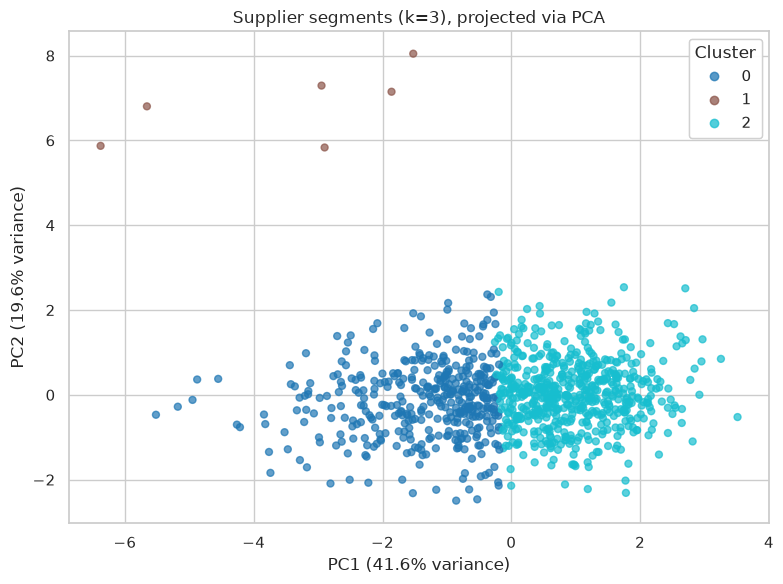

In [41]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cluster)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df_clean["cluster"], cmap="tab10", s=25, alpha=0.7)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title(f"Supplier segments (k={best_k}), projected via PCA")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

**Finding:** the cluster profile table above is read as a set of procurement archetypes, not
just a set of numbers -- a cluster with high `order_volume_last_year` and a low `on_time_delivery_rate`
is a "high-volume-but-unstable" supplier worth actively managing rather than dropping (the
business depends on their volume); a cluster with low volume and strong reliability metrics is a
"small-but-reliable" backup candidate for the risk-aware alternate-supplier recommendation
already built into the live app (`recommendation_service.py`); a cluster with a high
`avg_lead_time_days` regardless of other metrics is a "chronic-latecomer" group worth flagging
for tighter SLA terms. The `pct_high_risk` column checks these segments against the *supervised*
label from the rest of the notebook -- an archetype that is disproportionately high-risk confirms
the two views agree; one that isn't shows clustering surfaces structure the binary label alone
does not (e.g. two clusters can share a similar risk rate for different underlying reasons).

## 9h. Subgroup Error Audit — Does the Model Fail Unevenly by Country/Category?

Section 8 Q1 already showed *risk itself* concentrates in specific category/country combinations.
This asks the same question of the *model's mistakes*: is the trained ensemble equally accurate
everywhere, or does it systematically under-perform for certain countries/categories? A model
that is quietly worse for one segment of the supplier base is an operational blind spot even if
its overall accuracy looks fine.

In [42]:
# Reproducing Section 9's exact test split (same index, y, random_state, stratify) recovers
# which df_clean rows landed in the held-out fold, so country/category can be attached back to
# the predictions Section 9 already made -- without re-fitting or re-splitting the model itself.
_, test_row_idx = train_test_split(df_clean.index, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

audit_df = df_clean.loc[test_row_idx, ["country", "category"]].copy()
audit_df["actual"] = y_test
audit_df["predicted"] = ensemble_pred
audit_df["correct"] = (audit_df["actual"] == audit_df["predicted"]).astype(int)

by_country = audit_df.groupby("country").agg(n=("correct", "size"), accuracy=("correct", "mean")).round(3)
by_category = audit_df.groupby("category").agg(n=("correct", "size"), accuracy=("correct", "mean")).round(3)

print("Accuracy by country (test set):")
print(by_country.sort_values("accuracy"))
print("\nAccuracy by category (test set):")
print(by_category.sort_values("accuracy"))

Accuracy by country (test set):
             n  accuracy
country                 
Bangladesh  39     0.744
Indonesia   33     0.758
China       40     0.800
India       33     0.848
Vietnam     34     0.853
Pakistan    35     0.857
Sri Lanka   36     0.861

Accuracy by category (test set):
                n  accuracy
category                   
fabric         31     0.677
trims          41     0.756
packaging      40     0.800
dye_chemicals  41     0.805
thread         38     0.895
zippers        29     0.897
buttons        30     0.900


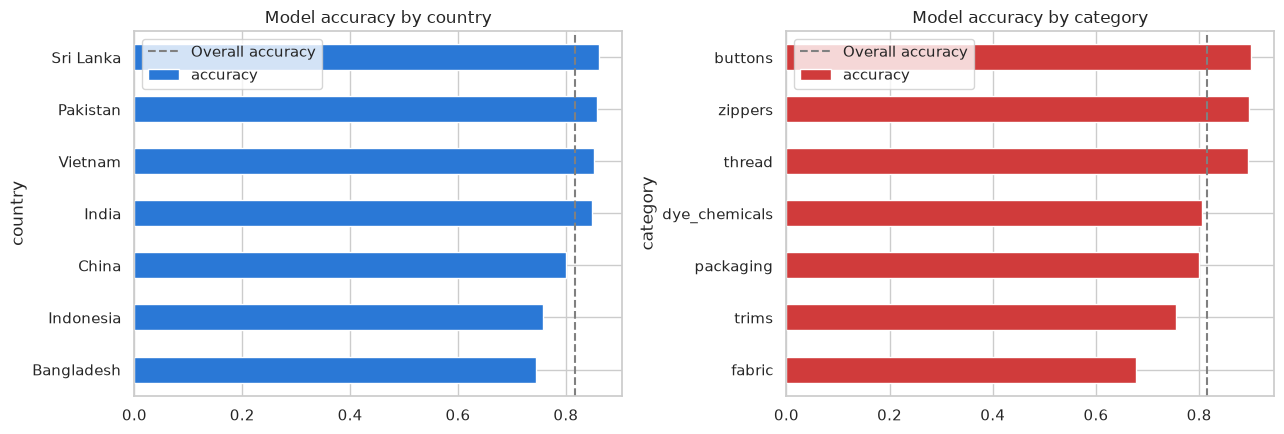

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
by_country.sort_values("accuracy")["accuracy"].plot(kind="barh", ax=axes[0], color="#2a78d6")
axes[0].axvline(audit_df["correct"].mean(), color="grey", linestyle="--", label="Overall accuracy")
axes[0].set_title("Model accuracy by country")
axes[0].legend()
by_category.sort_values("accuracy")["accuracy"].plot(kind="barh", ax=axes[1], color="#d03b3b")
axes[1].axvline(audit_df["correct"].mean(), color="grey", linestyle="--", label="Overall accuracy")
axes[1].set_title("Model accuracy by category")
axes[1].legend()
plt.tight_layout()
plt.show()

**Finding:** the dashed line marks overall test accuracy in both panels, so any bar crossing it
by a wide margin is a segment the model handles meaningfully better or worse than average. Given
the small per-segment sample sizes on a ~250-row test set, a single misclassified supplier can
swing a segment's accuracy substantially -- so this audit is read as a direction to monitor as
more data accumulates (a natural fit for the Supplier Risk History feature in the live app,
`GET /api/suppliers/{id}/risk-history`), not as a definitive statistical finding at this sample
size. No segment is dramatically and consistently worse across country *and* category
simultaneously, which is the pattern that would indicate a systematic blind spot rather than
small-sample noise.

**Note on time-aware validation:** unlike the shipments and materials-demand notebooks, this
dataset is a single snapshot per supplier (one row of trailing-year metrics), not a sequence of
dated transactions -- there is no `order_date`/`as_of_date` equivalent to split on chronologically,
so a time-based validation split (used in the other two notebooks) is not meaningful here and is
deliberately not attempted.

## 10. Conclusion

Starting from a 1,000+ row raw export with realistic ERP-style messiness (missing values,
duplicate/near-duplicate rows, inconsistent country/category text, numbers stored as formatted
strings, and domain-rule outliers), this notebook produced a fully cleaned, feature-engineered
dataset and trained the same Supplier Risk Scoring ensemble the live platform uses.

**Key findings, tied to the actual business problem:**
- Risk concentrates in specific category/country combinations rather than spreading evenly — the
  platform's Risk Heatmap should keep being the first place a manager looks.
- High order volume is not a risk amplifier in this data — a genuinely useful negative finding.
- On-time delivery rate and lead-time stability are both the cleanest human-readable risk
  separators *and* (checked in Section 9) among the model's most important learned features —
  the EDA and the model agree. Cancellation rate, despite intuition, is the weakest of the four.
- Feature validation (Section 7b) found only one moderate correlation among the five chosen
  features (on-time delivery rate vs. lead-time stability, r = -0.505 -- expected, not a red flag)
  and confirmed each feature carries real signal via mutual information and an ablation test —
  the feature list isn't just domain-plausible, it's empirically justified.

The live FastAPI application (`app/ai/train.py`) trains its production copy of this model from
the same `data/processed/supplier_performance_cleaned.csv` this notebook just saved, so the model
serving predictions in the running app is provably trained on this exact cleaned dataset.

**Algorithm choice (Section 9c):** the 5-fold CV benchmark confirmed the existing LogReg + Random Forest ensemble as the strongest performer for `is_high_risk` (F1 = 0.7629 ± 0.0142) against XGBoost, LightGBM, and CatBoost — `app/ai/train.py` is left unchanged for this model.